##Problem Statement

**Business Context**

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S. Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).

**Objective**

**ReneWind** is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data on generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set, and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators can be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

True positives (TP) are failures correctly predicted by the model. These will result in repair costs.
False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
False positives (FP) are detections where there is no failure. These will result in inspection costs.
It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variable should be considered as “failure” and “0” represents “No failure”.

**Installing and Importing the Necessary Libraries**

In [1]:
# Installing the libraries with the specified version
!pip install --no-deps tensorflow==2.19.0 scikit-learn==1.6.1 matplotlib===3.10.0 seaborn==0.13.2 numpy==2.0.2 pandas==2.2.2 -q --user --no-warn-script-location

In [2]:
# Library for data manipulation and analysis.
import pandas as pd
# Fundamental package for scientific computing.
import numpy as np
#splitting datasets into training and testing sets.
from sklearn.model_selection import train_test_split
#Imports tools for data preprocessing including label encoding, one-hot encoding, and standard scaling
from sklearn.preprocessing import LabelEncoder, OneHotEncoder,StandardScaler
#Imports a class for imputing missing values in datasets.
from sklearn.impute import SimpleImputer
#Imports the Matplotlib library for creating visualizations.
import matplotlib.pyplot as plt
# Imports the Seaborn library for statistical data visualization.
import seaborn as sns
# Time related functions.
import time
#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report


#Imports the tensorflow,keras and layers.
import tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dense, Input, Dropout,BatchNormalization
from tensorflow.keras import backend

# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
tf.keras.utils.set_random_seed(812)

# If using TensorFlow, this will make GPU ops as deterministic as possible,
# but it will affect the overall performance, so be mindful of that.
tf.config.experimental.enable_op_determinism()

## Loading the Data

In [4]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
Rene_Train = pd.read_csv('/content/drive/MyDrive/Santhosh-Notebooks/NeuralNetworks/Train.csv')
Rene_Test=pd.read_csv('/content/drive/MyDrive/Santhosh-Notebooks/NeuralNetworks/Test.csv')

###Make a Copy of the Data

In [6]:
Data=Rene_Train.copy()
Data_Test=Rene_Test.copy()

**Important Note**

The training dataset will be used for model development and hyperparameter tuning, while the test dataset will be kept completely unseen and used only for evaluating the final selected model.

## Data Overview

###Overview for Train data set

####Checking the number of rows and columns in the data

In [7]:

Data.shape

(20000, 41)

#### Displaying the first few rows of the Train dataset

In [8]:
# Let's view the first 5 rows of the data
Data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,...,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,...,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,...,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,...,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,...,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0


#### Displaying the last few rows of the Train dataset

In [9]:
# Let's view the last 5 rows of the data
Data.tail()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
19995,-2.071318,-1.088279,-0.796174,-3.011720,-2.287540,2.807310,0.481428,0.105171,-0.586599,-2.899398,...,-8.273996,5.745013,0.589014,-0.649988,-3.043174,2.216461,0.608723,0.178193,2.927755,1
19996,2.890264,2.483069,5.643919,0.937053,-1.380870,0.412051,-1.593386,-5.762498,2.150096,0.272302,...,-4.159092,1.181466,-0.742412,5.368979,-0.693028,-1.668971,3.659954,0.819863,-1.987265,0
19997,-3.896979,-3.942407,-0.351364,-2.417462,1.107546,-1.527623,-3.519882,2.054792,-0.233996,-0.357687,...,7.112162,1.476080,-3.953710,1.855555,5.029209,2.082588,-6.409304,1.477138,-0.874148,0
19998,-3.187322,-10.051662,5.695955,-4.370053,-5.354758,-1.873044,-3.947210,0.679420,-2.389254,5.456756,...,0.402812,3.163661,3.752095,8.529894,8.450626,0.203958,-7.129918,4.249394,-6.112267,0
19999,-2.686903,1.961187,6.137088,2.600133,2.657241,-4.290882,-2.344267,0.974004,-1.027462,0.497421,...,6.620811,-1.988786,-1.348901,3.951801,5.449706,-0.455411,-2.202056,1.678229,-1.974413,0


#### Checking for missing values and Datatypes of the Columns

In [10]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22

#### Duplicate Values

In [11]:
#Checking for duplicate values
Data.duplicated().sum()

np.int64(0)

####Observations for structure of Training dataset

* The dataset contains 20,000 observations and 41 variables, including 40 predictor variables (V1–V40) and 1 target variable (Target) indicating generator failure.

* All predictor variables are continuous numerical features stored as float64, representing anonymized sensor readings collected from wind turbines.

* ***The target variable is binary, where 1 represents generator failure and 0 represents normal operation.***

* The feature values contain both positive and negative numbers, indicating that the data appears to be standardized or transformed sensor measurements.

* A small number of missing values are present in V1 and V2, while all other variables contain complete observations.

* There are no duplicate values present in the training dataset

* The dataset size is relatively small (≈6.3 MB), making it efficient for training machine learning models.

Since the problem involves predicting turbine failures, special attention will be given to evaluation metrics such as Recall, as missing a failure (false negative) can lead to higher maintenance costs.

####Statistical Summary

In [12]:
Data.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
count,19982.000000,19982.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,-0.271996,0.440430,2.484699,-0.083152,-0.053752,-0.995443,-0.879325,-0.548195,-0.016808,-0.012998,...,0.303799,0.049825,-0.462702,2.229620,1.514809,0.011316,-0.344025,0.890653,-0.875630,0.055500
std,3.441625,3.150784,3.388963,3.431595,2.104801,2.040970,1.761626,3.295756,2.160568,2.193201,...,5.500400,3.575285,3.183841,2.937102,3.800860,1.788165,3.948147,1.753054,3.012155,0.228959
min,-11.876451,-12.319951,-10.708139,-15.082052,-8.603361,-10.227147,-7.949681,-15.657561,-8.596313,-9.853957,...,-19.876502,-16.898353,-17.985094,-15.349803,-14.833178,-5.478350,-17.375002,-6.438880,-11.023935,0.000000
25%,-2.737146,-1.640674,0.206860,-2.347660,-1.535607,-2.347238,-2.030926,-2.642665,-1.494973,-1.411212,...,-3.420469,-2.242857,-2.136984,0.336191,-0.943809,-1.255819,-2.987638,-0.272250,-2.940193,0.000000
50%,-0.747917,0.471536,2.255786,-0.135241,-0.101952,-1.000515,-0.917179,-0.389085,-0.067597,0.100973,...,0.052073,-0.066249,-0.255008,2.098633,1.566526,-0.128435,-0.316849,0.919261,-0.920806,0.000000
75%,1.840112,2.543967,4.566165,2.130615,1.340480,0.380330,0.223695,1.722965,1.409203,1.477045,...,3.761722,2.255134,1.436935,4.064358,3.983939,1.175533,2.279399,2.057540,1.119897,0.000000
max,15.493002,13.089269,17.090919,13.236381,8.133797,6.975847,8.006091,11.679495,8.137580,8.108472,...,23.633187,16.692486,14.358213,15.291065,19.329576,7.467006,15.289923,7.759877,10.654265,1.000000


In [13]:
Data['Target'].value_counts()

,count
Target,
0,18890
1,1110


* The mean values of most features are close to zero, suggesting that the data has likely been standardized or transformed before being shared.

* The target variable has a mean of approximately 0.055, indicating that generator failures occur in roughly 5–6% of the observations, suggesting a class imbalance problem. The same is confirmed by value count distribution of dependent feature Target

* Since failures are relatively rare compared to normal operations, techniques such as class weighting and recall-based evaluation metrics will be important during model training.

###Overview for Test data set

####Checking the number of rows and columns in the dataset

In [14]:
Data_Test.shape

(5000, 41)

#### Displaying the first and last few rows of the Test dataset

In [15]:
Data_Test.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-0.613489,-3.819640,2.202302,1.300420,-1.184929,-4.495964,-1.835817,4.722989,1.206140,-0.341909,...,2.291204,-5.411388,0.870073,0.574479,4.157191,1.428093,-10.511342,0.454664,-1.448363,0
1,0.389608,-0.512341,0.527053,-2.576776,-1.016766,2.235112,-0.441301,-4.405744,-0.332869,1.966794,...,-2.474936,2.493582,0.315165,2.059288,0.683859,-0.485452,5.128350,1.720744,-1.488235,0
2,-0.874861,-0.640632,4.084202,-1.590454,0.525855,-1.957592,-0.695367,1.347309,-1.732348,0.466500,...,-1.318888,-2.997464,0.459664,0.619774,5.631504,1.323512,-1.752154,1.808302,1.675748,0
3,0.238384,1.458607,4.014528,2.534478,1.196987,-3.117330,-0.924035,0.269493,1.322436,0.702345,...,3.517918,-3.074085,-0.284220,0.954576,3.029331,-1.367198,-3.412140,0.906000,-2.450889,0
4,5.828225,2.768260,-1.234530,2.809264,-1.641648,-1.406698,0.568643,0.965043,1.918379,-2.774855,...,1.773841,-1.501573,-2.226702,4.776830,-6.559698,-0.805551,-0.276007,-3.858207,-0.537694,0


In [16]:
Data_Test.tail()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
4995,-5.120451,1.634804,1.251259,4.035944,3.291204,-2.932230,-1.328662,1.754066,-2.984586,1.248633,...,9.979118,0.063438,0.217281,3.036388,2.109323,-0.557433,1.938718,0.512674,-2.694194,0
4996,-5.172498,1.171653,1.579105,1.219922,2.529627,-0.668648,-2.618321,-2.000545,0.633791,-0.578938,...,4.423900,2.603811,-2.152170,0.917401,2.156586,0.466963,0.470120,2.196756,-2.376515,0
4997,-1.114136,-0.403576,-1.764875,-5.879475,3.571558,3.710802,-2.482952,-0.307614,-0.921945,-2.999141,...,3.791778,7.481506,-10.061396,-0.387166,1.848509,1.818248,-1.245633,-1.260876,7.474682,0
4998,-1.703241,0.614650,6.220503,-0.104132,0.955916,-3.278706,-1.633855,-0.103936,1.388152,-1.065622,...,-4.100352,-5.949325,0.550372,-1.573640,6.823936,2.139307,-4.036164,3.436051,0.579249,0
4999,-0.603701,0.959550,-0.720995,8.229574,-1.815610,-2.275547,-2.574524,-1.041479,4.129645,-2.731288,...,2.369776,-1.062408,0.790772,4.951955,-7.440825,-0.069506,-0.918083,-2.291154,-5.362891,0


####Check for Duplicate Values

In [17]:
Data_Test.duplicated().sum()

np.int64(0)

#### Checking for missing values and Datatypes of the Columns

In [18]:
Data_Test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      4995 non-null   float64
 1   V2      4994 non-null   float64
 2   V3      5000 non-null   float64
 3   V4      5000 non-null   float64
 4   V5      5000 non-null   float64
 5   V6      5000 non-null   float64
 6   V7      5000 non-null   float64
 7   V8      5000 non-null   float64
 8   V9      5000 non-null   float64
 9   V10     5000 non-null   float64
 10  V11     5000 non-null   float64
 11  V12     5000 non-null   float64
 12  V13     5000 non-null   float64
 13  V14     5000 non-null   float64
 14  V15     5000 non-null   float64
 15  V16     5000 non-null   float64
 16  V17     5000 non-null   float64
 17  V18     5000 non-null   float64
 18  V19     5000 non-null   float64
 19  V20     5000 non-null   float64
 20  V21     5000 non-null   float64
 21  V22     5000 non-null   float64
 22  

####Observations for structure of Test dataset

* The test dataset contains 5,000 observations and 41 variables, which is consistent with the structure of the training dataset.

* The dataset includes 40 predictor variables (V1–V40) representing anonymized sensor readings and 1 target variable (Target) indicating generator failure.

* All predictor variables are numerical features stored as float64, while the target variable is binary (int64) where 1 represents failure and 0 represents normal operation.

* A small number of missing values are present in variables V1 and V2, similar to the training dataset. All other variables contain complete observations.

* No duplicate rows were detected in the dataset, indicating that each observation represents a unique turbine record.

* The feature value ranges contain both positive and negative numbers, suggesting that the data has likely been standardized or transformed before sharing.

***The overall structure, feature types, and distributions of the test dataset closely match the training dataset, confirming that the datasets are consistent and suitable for evaluating model performance.***

##Exploratory Data Analysis (EDA)

###Helper Functions

In [19]:
 #Function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [20]:
# Function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

###Univariate Analysis





####Target

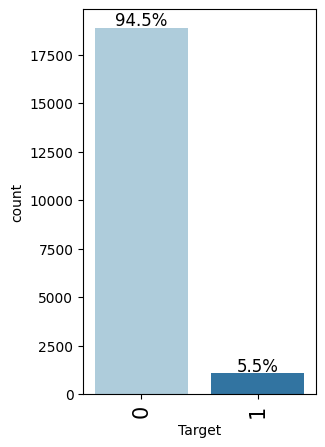

In [21]:
labeled_barplot(Data,"Target",perc=True)

* The target variable represents generator failure, where 0 indicates no failure and 1 indicates failure.

* The dataset shows a significant class imbalance, with approximately 94.5% of observations belonging to the non-failure class and only 5.5% representing failure cases.

* Since failures are rare, a model that predicts only the majority class (no failure) could still achieve high accuracy but would fail to detect actual failures.

* Therefore, evaluating the model using the confusion matrix becomes important, as it helps analyze:

      True positives (TP) are failures correctly predicted by the model. These will result in repair costs.

      False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.

      False positives (FP) are detections where there is no failure. These will result in inspection costs.

***In this problem, False Negatives are particularly costly, because missing a failure could lead to generator breakdown and expensive replacement.Therefore, during model development, we will focus on metrics derived from the confusion matrix, such as Recall, to ensure the model effectively detects generator failures.***

####BoxPlot for all the 40 features in the dataset

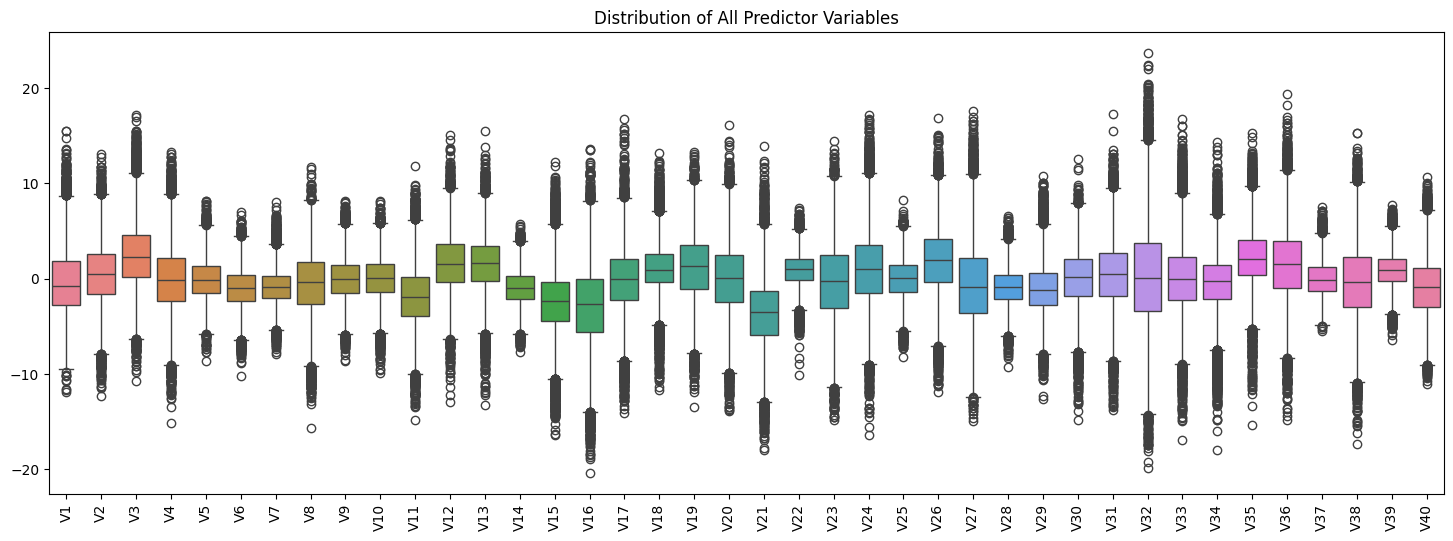

In [22]:
plt.figure(figsize=(18,6))

sns.boxplot(data=Data.drop("Target", axis=1))

plt.title("Distribution of All Predictor Variables")
plt.xticks(rotation=90)

plt.show()


* Most predictor variables appear to be centered around zero, suggesting that the features have likely been standardized or transformed before sharing.

* The spread of values differs across features, indicating that some sensor measurements show greater variability than others.

* Several variables contain extreme values outside the whiskers, indicating the presence of potential outliers or rare sensor readings.

###Bi-Variate Analysis

####Studying correlation between features

Since the dataset contains a large number of predictor variables (V1–V40), visualizing all features against the target variable would result in too many plots and make interpretation difficult. Therefore, correlation analysis is used to identify the features most associated with generator failure. The top variables with the highest correlation with the target variable are then selected for further visualization, allowing us to focus on the features that are most likely to provide meaningful insights.

In [23]:
# Compute correlation of all variables with Target
corr_target = Data.corr()["Target"].drop("Target")

# Display correlations
corr_target

,Target
V1,0.073307
V2,-0.000946
V3,-0.213855
V4,0.110786
V5,-0.100525
V6,0.000237
V7,0.236907
V8,0.135996
V9,0.008124
V10,-0.051263


In [24]:
# Sort correlations by absolute value
corr_target_abs = corr_target.abs().sort_values(ascending=False)

# Display top correlated variables
corr_target_abs.head(10)

,Target
V18,0.293340
V21,0.256411
V15,0.249118
V7,0.236907
V16,0.230507
V39,0.227264
V36,0.216453
V3,0.213855
V28,0.207359
V11,0.196715


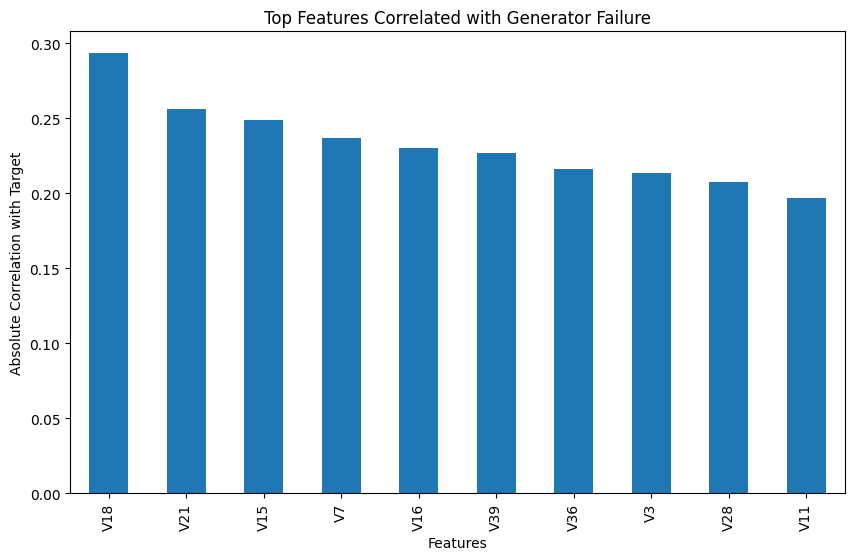

In [25]:
plt.figure(figsize=(10,6))

corr_target_abs.head(10).plot(kind="bar")

plt.title("Top Features Correlated with Generator Failure")
plt.ylabel("Absolute Correlation with Target")
plt.xlabel("Features")

plt.show()



1. The correlation analysis shows that the predictor variables have moderate
relationships with the target variable, with the highest correlations being below 0.30. This indicates that no single feature strongly determines generator failure. Instead, generator failures are likely influenced by a combination of multiple sensor measurements interacting together.

2. This characteristic of the data makes machine learning models capable of capturing complex nonlinear relationships particularly suitable for this problem. Neural networks, in particular, can learn interactions between multiple features simultaneously and identify hidden patterns that may signal an upcoming generator failure.

 ***Thus, rather than relying on a small set of highly correlated variables, the neural network model will utilize all available sensor features (V1–V40) to learn the combined patterns associated with generator failures***

###EDA Conclusion

The exploratory data analysis revealed that the dataset consists of 40 anonymized numerical predictor variables and a binary target variable indicating generator failure. The target variable shows a clear class imbalance, with failures representing a small portion of the observations. Distribution analysis of the predictor variables indicates varying spreads and the presence of potential outliers, while correlation analysis suggests that no single feature strongly determines failure. This implies that generator failures are likely influenced by the interaction of multiple sensor readings. Therefore, neural network models are well suited for this problem, as they can capture complex nonlinear relationships and interactions among multiple features.

##Data Preprocessing  

###Handling Missing Values

From the earlier data inspection, we observed that V1 and V2 contain a small number of missing values, while all other variables have complete observations.

Since the number of missing values is very small relative to the dataset size, we can impute them using the mean of the respective columns.

In [26]:
# Check missing values
Data.isnull().sum()

,0
V1,18
V2,18
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


* **we can see that there are 18 rows which doesnot have values for V1 and V2 columns**

we will now impute these columns for mean values of respective columns

In [27]:
# Impute missing values using column mean
Data.fillna(Data.mean(), inplace=True)

In [28]:
# Check missing values after imputing the columns
Data.isnull().sum()

,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


We verified that there no more missing values in the any of the columns.

##Data Preparation for Modeling

In [29]:
X = Data.drop("Target", axis=1)
y = Data["Target"]

In [30]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

###Applying Scaling

In [31]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)

Feature scaling was applied using StandardScaler. The scaler was fitted only on the training data and then applied to the validation data to avoid data leakage. This ensures that information from the validation dataset does not influence the training process.

Feature scaling is particularly important for neural networks because gradient-based optimization algorithms such as stochastic gradient descent (SGD) perform better when input features are on similar scales.

##Choice of Evaluation Metric

1. The objective of this problem is to predict generator failures in wind turbines so that maintenance can be performed before the generator breaks down. From the business context, different prediction outcomes lead to different costs.

2. Correctly predicting a failure allows the company to repair the generator early, which is relatively inexpensive. However, if the model fails to detect a real failure (False Negative), the generator may break down completely, leading to very high replacement costs and operational downtime.

3. Since the cost of missing a failure is significantly higher than the cost of performing an unnecessary inspection, the model should prioritize detecting as many failure cases as possible.

***Therefore, Recall is chosen as the primary evaluation metric, as it measures the model’s ability to correctly identify actual failure events. Using Recall helps ensure that the model minimizes missed failures and supports the goal of predictive maintenance and cost reduction.***

##Model Building

###Utility Functions

In [32]:
def plot(history, name):
    """
    Function to plot loss/accuracy

    history: an object which stores the metrics and losses.
    name: can be one of Loss or Accuracy
    """
    fig, ax = plt.subplots() #Creating a subplot with figure and axes.
    plt.plot(history.history[name]) #Plotting the train accuracy or train loss
    plt.plot(history.history['val_'+name]) #Plotting the validation accuracy or validation loss

    plt.title('Model ' + name.capitalize()) #Defining the title of the plot.
    plt.ylabel(name.capitalize()) #Capitalizing the first letter.
    plt.xlabel('Epoch') #Defining the label for the x-axis.
    fig.legend(['Train', 'Validation'], loc="outside right upper") #Defining the legend, loc controls the position of the legend.

In [33]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors) > threshold
    # pred_temp = model.predict(predictors) > threshold
    # # rounding off the above values to get classes
    # pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='weighted')  # to compute Recall
    precision = precision_score(target, pred, average='weighted')  # to compute Precision
    f1 = f1_score(target, pred, average='weighted')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},
        index=[0],
    )

    return df_perf

###Model-1 (SGD Optimizer)

In [34]:
# defining the batch size and  epochs upfront
epochs = 20
batch_size = 32

As a starting point, a baseline neural network model is constructed using the Sequential API. The network consists of two hidden layers with 32 and 16 neurons respectively, both using the ReLU activation function, followed by a single neuron output layer with a sigmoid activation for binary classification. The model is trained using the Stochastic Gradient Descent (SGD) optimizer and binary cross-entropy loss.

In [35]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [36]:
#Initializing the neural network
model = Sequential()
model.add(Dense(32,activation="relu",input_dim=X_train.shape[1]))
model.add(Dense(16,activation="relu"))
model.add(Dense(1,activation="sigmoid"))

In [37]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,857 (7.25 KB)

 Trainable params: 1,857 (7.25 KB)

 Non-trainable params: 0 (0.00 B)

The model summary shows the structure of the neural network, including the number of neurons in each layer and the total number of trainable parameters. The model contains 1,857 trainable parameters, which represent the weights and biases that will be optimized during training.

In [38]:
optimizer = tf.keras.optimizers.SGD()    # defining SGD as the optimizer to be used
model.compile(loss='binary_crossentropy', optimizer=optimizer)

In [39]:
start = time.time()
history = model.fit(X_train, y_train, validation_data=(X_valid,y_valid) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4575 - val_loss: 0.1708
Epoch 2/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1610 - val_loss: 0.1345
Epoch 3/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1289 - val_loss: 0.1168
Epoch 4/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1120 - val_loss: 0.1057
Epoch 5/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1015 - val_loss: 0.0984
Epoch 6/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0940 - val_loss: 0.0928
Epoch 7/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0881 - val_loss: 0.0881
Epoch 8/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0830 - val_loss: 0.0841
Epoch 9/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0786 - val_loss: 0.0808
Epoch 10/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0747 - val_loss: 0.0779
Epoch 11/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0713 - val_loss: 0.0755
Epoch 12/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

In [40]:
print("Time taken in seconds ",end-start)

Time taken in seconds  22.682408571243286


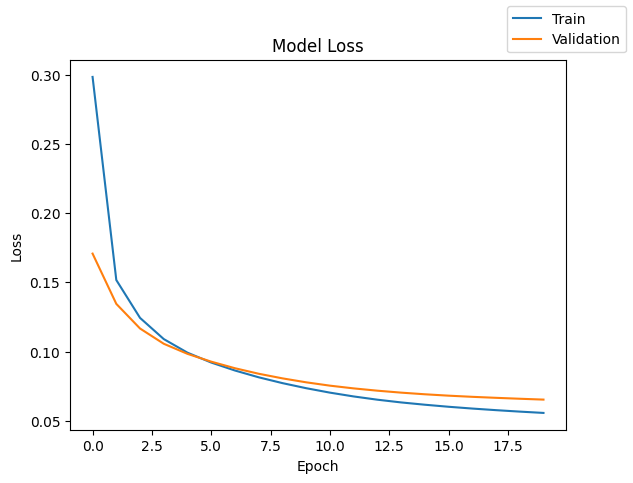

In [41]:
plot(history,'loss')

In [42]:
model_1_train_perf = model_performance_classification(model, X_train, y_train)
model_1_train_perf

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.988429,0.988429,0.988255,0.987962


In [43]:
model_1_valid_perf = model_performance_classification(model, X_valid, y_valid)
model_1_valid_perf

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.987833,0.987833,0.987666,0.987294


####Model-1 Performance (SGD Optimizer)

* The training history shows that the loss steadily decreases across epochs for both the training and validation datasets, indicating that the model is learning useful patterns from the data. The validation loss closely follows the training loss throughout the training process, suggesting that the model is not significantly overfitting.

* From the performance metrics, the model achieves a training accuracy of approximately 98.8% and validation accuracy of approximately 98.7%. The recall score is also very high (~0.987), indicating that the model is able to correctly identify most of the generator failure cases.

* Additionally, the similarity between training and validation metrics suggests that the model generalizes well to unseen data, as there is no large performance gap between the two datasets.

***Overall, the baseline neural network model using the SGD optimizer performs well, successfully capturing relationships between the sensor variables and generator failure. However, further experimentation with different optimizers, additional layers, dropout, and class weighting will be conducted to explore whether the model performance can be further improved.***

###Model-2 Neural Network with Additional Hidden Layer

To explore whether a deeper neural network can better capture complex patterns in the data, a second model will be constructed by adding an additional hidden layer to the baseline architecture. The new network consists of three hidden layers with 64, 32, and 16 neurons respectively, each using the ReLU activation function, followed by a single neuron output layer with sigmoid activation for binary classification.

Increasing the number of hidden layers allows the network to learn more complex hierarchical relationships among the input features. In this dataset, generator failure is likely influenced by interactions among multiple sensor readings, rather than a single feature. A deeper architecture can potentially capture these interactions more effectively by learning progressively richer feature representations across layers.

In [44]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [45]:
#Initializing the neural network
model = Sequential()
model.add(Dense(64,activation="relu",input_dim=X_train.shape[1]))
model.add(Dense(32,activation="relu"))
model.add(Dense(16,activation="relu"))
model.add(Dense(1,activation="sigmoid"))

In [46]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,249 (20.50 KB)

 Trainable params: 5,249 (20.50 KB)

 Non-trainable params: 0 (0.00 B)

The model summary shows that the network now contains 5,249 trainable parameters, compared to 1,857 parameters in the baseline model. The increase in parameters allows the model to learn more complex relationships among the 40 input features, though it may also increase the risk of overfitting if the model becomes too complex.

In [47]:
optimizer = tf.keras.optimizers.SGD()    # defining SGD as the optimizer to be used
model.compile(loss='binary_crossentropy', optimizer=optimizer)

In [48]:
start = time.time()
history = model.fit(X_train, y_train, validation_data=(X_valid,y_valid) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3521 - val_loss: 0.1715
Epoch 2/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1594 - val_loss: 0.1320
Epoch 3/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1234 - val_loss: 0.1094
Epoch 4/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1015 - val_loss: 0.0955
Epoch 5/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0873 - val_loss: 0.0867
Epoch 6/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0774 - val_loss: 0.0806
Epoch 7/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0703 - val_loss: 0.0763
Epoch 8/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0652 - val_loss: 0.0730
Epoch 9/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0612 - val_loss: 0.0705
Epoch 10/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0582 - val_loss: 0.0684
Epoch 11/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0557 - val_loss: 0.0667
Epoch 12/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

In [49]:
print("Time taken in seconds ",end-start)

Time taken in seconds  24.705059051513672


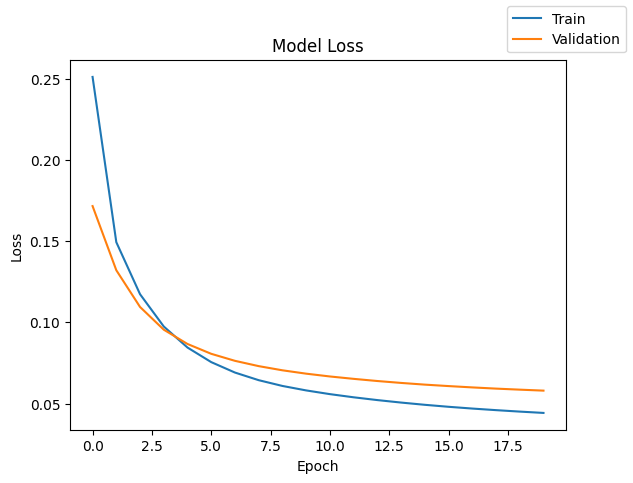

In [50]:
plot(history,'loss')

In [51]:
model_2_train_perf = model_performance_classification(model, X_train, y_train)
model_2_train_perf

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.9925,0.9925,0.992464,0.99229


In [52]:
model_2_valid_perf = model_performance_classification(model, X_valid, y_valid)
model_2_valid_perf

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.989333,0.989333,0.98921,0.988924


####Model-2 Performance (Additional Hidden Layer)

* The second model introduces an additional hidden layer, resulting in a deeper neural network architecture with 64, 32, and 16 neurons in the hidden layers. The objective of this modification was to allow the model to learn more complex interactions among the input variables.

* From the training process, the training and validation loss both decrease steadily across epochs, indicating that the model continues to learn useful patterns from the data. The validation loss closely follows the training loss, suggesting that the model does not exhibit significant overfitting.

* In terms of performance metrics, the model achieves a training accuracy of approximately 99.25% and validation accuracy of approximately 98.93%. The recall score on the validation dataset is around 0.989, indicating that the model correctly identifies most of the generator failure cases.

***Compared to the baseline model, Model-2 shows a slight improvement in performance, suggesting that increasing the depth of the neural network helps capture more complex relationships among the sensor variables. However, the improvement is relatively small, indicating that the baseline architecture was already effective for this dataset.***



###Mode-3 Neural Network With Adam Optimizer

To further improve the model performance, the next experiment will involve changing the optimization algorithm used for training the neural network. While the previous models used Stochastic Gradient Descent (SGD), this model will use the Adam optimizer, which is an adaptive learning rate optimization algorithm that often provides faster and more stable convergence during training.

The architecture of the network will remain the same as Model-2, consisting of three hidden layers with 64, 32, and 16 neurons respectively, each using the ReLU activation function, followed by a single neuron output layer with sigmoid activation for binary classification. Keeping the architecture unchanged will allow us to isolate the impact of the optimizer on model performance.

The Adam optimizer will dynamically adjust the learning rate for each parameter during training, which may help the model converge more efficiently and potentially achieve better performance. By comparing this model with the previous SGD-based models, we will evaluate whether using an adaptive optimizer improves the network’s ability to detect generator failures.

In [53]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [54]:
#Initializing the neural network
model = Sequential()
model.add(Dense(64,activation="relu",input_dim=X_train.shape[1]))
model.add(Dense(32,activation="relu"))
model.add(Dense(16,activation="relu"))
model.add(Dense(1,activation="sigmoid"))

In [55]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,249 (20.50 KB)

 Trainable params: 5,249 (20.50 KB)

 Non-trainable params: 0 (0.00 B)

The model summary shows that the network now contains 5,249 trainable parameters, compared to 1,857 parameters in the baseline model. This is same as the previous model we analyzed.

In [56]:
optimizer = tf.keras.optimizers.Adam()    # defining Adam as the optimizer to be used
model.compile(loss='binary_crossentropy', optimizer=optimizer)

In [57]:
start = time.time()
history = model.fit(X_train, y_train, validation_data=(X_valid,y_valid) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.2227 - val_loss: 0.0792
Epoch 2/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0658 - val_loss: 0.0632
Epoch 3/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0494 - val_loss: 0.0592
Epoch 4/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0420 - val_loss: 0.0564
Epoch 5/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0379 - val_loss: 0.0554
Epoch 6/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0348 - val_loss: 0.0552
Epoch 7/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0330 - val_loss: 0.0558
Epoch 8/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0316 - val_loss: 0.0558
Epoch 9/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0302 - val_loss: 0.0566
Epoch 10/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0286 - val_loss: 0.0576
Epoch 11/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0278 - val_loss: 0.0583
Epoch 12/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

In [58]:
print("Time taken in seconds ",end-start)

Time taken in seconds  28.980347871780396


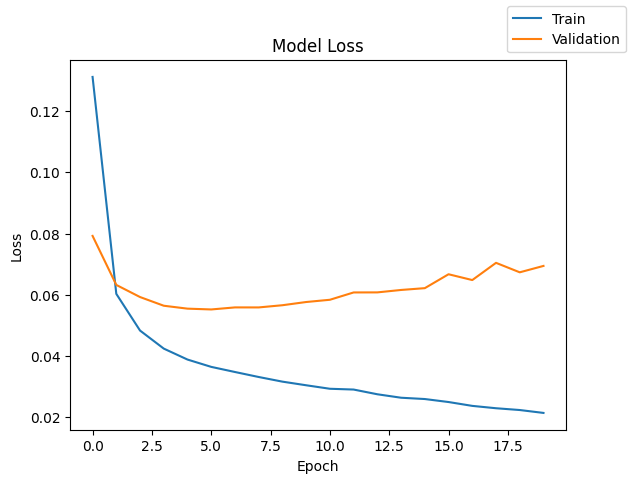

In [59]:
plot(history,'loss')

In [60]:
model_3_train_perf = model_performance_classification(model, X_train, y_train)
model_3_train_perf

438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.993857,0.993857,0.993897,0.993687


In [61]:
model_3_valid_perf = model_performance_classification(model, X_valid, y_valid)
model_3_valid_perf

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.989833,0.989833,0.989766,0.989435


####Model-3 Performance (Adam Optimizer)

* In this experiment, the optimizer was changed from Stochastic Gradient Descent (SGD) to the Adam optimizer, while keeping the neural network architecture unchanged. The purpose of this experiment was to evaluate whether an adaptive optimization algorithm could improve the model's learning efficiency and predictive performance.

* From the training process, the training loss decreases rapidly in the early epochs, indicating that the Adam optimizer enables faster convergence compared to SGD. However, after the initial epochs, the validation loss begins to gradually increase while the training loss continues to decrease, which suggests that the model starts to overfit the training data.

* In terms of performance metrics, the model achieves a training recall of approximately 0.9936 and a validation recall of approximately 0.989, indicating that the model correctly identifies a very high proportion of generator failure cases. Since recall represents the ability of the model to detect actual failures, maintaining a high recall is particularly important in this predictive maintenance scenario where missing a failure could result in higher replacement costs.

***Although the recall remains high, the increasing validation loss indicates that the model may not generalize as well as earlier models. Therefore, additional regularization techniques such as dropout will be explored in the next model to reduce overfitting and improve generalization.***

###Model-4 Neural Network with Dropout Regularization

The architecture of the model will remain similar to Model-3, consisting of three hidden layers with 64, 32, and 16 neurons respectively, each using the ReLU activation function, followed by a single neuron output layer with sigmoid activation for binary classification. However, Dropout layers will be added between the hidden layers to reduce the risk of overfitting.

By randomly dropping neurons during training, Dropout helps the model generalize better to unseen data by preventing the network from memorizing the training dataset. This is particularly useful in neural networks with multiple layers and a large number of parameters.

The Adam optimizer will continue to be used in this model to maintain fast convergence while evaluating whether the addition of Dropout improves the model’s ability to generalize and maintain high recall for generator failure detection.

In [62]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [63]:
#Initializing the neural network
model = Sequential()
model.add(Dense(64,activation="relu",input_dim=X_train.shape[1]))
model.add(Dropout(0.3))
model.add(Dense(32,activation="relu"))
model.add(Dropout(0.3))
model.add(Dense(16,activation="relu"))
model.add(Dense(1,activation="sigmoid"))

In [64]:
optimizer = tf.keras.optimizers.Adam()    # defining Adam as the optimizer to be used
model.compile(loss='binary_crossentropy', optimizer=optimizer)

In [65]:
start = time.time()
history = model.fit(X_train, y_train, validation_data=(X_valid,y_valid) , batch_size=batch_size, epochs=epochs)
end=time.time()

Epoch 1/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2567 - val_loss: 0.1008
Epoch 2/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1072 - val_loss: 0.0741
Epoch 3/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0841 - val_loss: 0.0653
Epoch 4/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0726 - val_loss: 0.0598
Epoch 5/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0680 - val_loss: 0.0568
Epoch 6/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0591 - val_loss: 0.0572
Epoch 7/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0587 - val_loss: 0.0559
Epoch 8/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0570 - val_loss: 0.0540
Epoch 9/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0514 - val_loss: 0.0540
Epoch 10/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0495 - val_loss: 0.0521
Epoch 11/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0470 - val_loss: 0.0513
Epoch 12/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

In [66]:
print("Time taken in seconds ",end-start)

Time taken in seconds  34.53999137878418


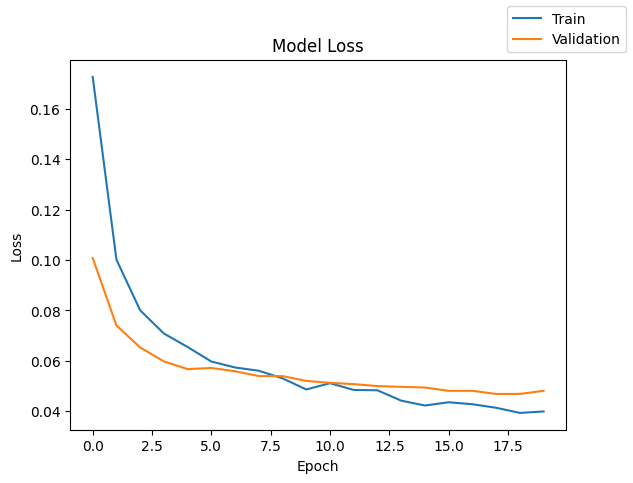

In [67]:
plot(history,'loss')

In [68]:
model_4_train_perf = model_performance_classification(model, X_train, y_train)
model_4_train_perf

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.9945,0.9945,0.994486,0.994387


In [69]:
model_4_valid_perf = model_performance_classification(model, X_valid, y_valid)
model_4_valid_perf

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.991333,0.991333,0.991206,0.991113


####Model-4 Performance (Dropout Regularization)

* In this experiment, Dropout layers were introduced into the neural network architecture to reduce overfitting observed in the previous model. Dropout randomly disables a fraction of neurons during training, preventing the model from relying too heavily on specific neurons and encouraging the network to learn more robust and generalized patterns.

* The training process shows that both training and validation loss decrease steadily during the early epochs, and the gap between them remains relatively small. Compared to Model-3, the validation loss remains more stable throughout the training process, indicating that the addition of Dropout helps reduce overfitting and improve generalization.

* In terms of performance metrics, the model achieves a training recall of approximately 0.9945 and a validation recall of approximately 0.9913, which indicates that the model is able to correctly identify a very high proportion of generator failure cases. Since recall is the most important metric in this predictive maintenance scenario—where missing a failure can lead to significantly higher replacement costs—maintaining high recall is particularly desirable.

***Overall, the addition of Dropout improves the model’s generalization ability while maintaining high recall and accuracy, making this model more robust compared to the previous architectures***.

### Model-5 Neural Network with Class Weights

* To further improve the model’s ability to detect generator failures, the next experiment will introduce class weights during the training process. The dataset used in this study is highly imbalanced, with the majority of observations corresponding to non-failure cases and only a small proportion representing actual generator failures. In such situations, machine learning models may become biased toward predicting the majority class, which can lead to missed failure detections.

* To address this issue, class weights will be applied during training, assigning a higher penalty to misclassifying the minority class (generator failures). By increasing the importance of failure observations in the loss function, the model will be encouraged to pay greater attention to these critical cases.

* The neural network architecture will remain the same as Model-4, consisting of three hidden layers with 64, 32, and 16 neurons respectively, each using the ReLU activation function, followed by a single neuron output layer with sigmoid activation for binary classification. Dropout layers will continue to be used to control overfitting, and the Adam optimizer will be retained to maintain efficient convergence.

In [70]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [71]:
#Initializing the neural network
model = Sequential()
model.add(Dense(64,activation="relu",input_dim=X_train.shape[1]))
model.add(Dropout(0.3))
model.add(Dense(32,activation="relu"))
model.add(Dropout(0.3))
model.add(Dense(16,activation="relu"))
model.add(Dense(1,activation="sigmoid"))

In [72]:
optimizer = tf.keras.optimizers.Adam()    # defining Adam as the optimizer to be used
model.compile(loss='binary_crossentropy', optimizer=optimizer)

**compute_class_weight**

compute_class_weight is a function from scikit-learn that automatically calculates weights for each class in an imbalanced dataset. These weights are used during model training to give more importance to minority classes, ensuring that the model does not become biased toward the majority class.

The function calculates weights inversely proportional to class frequencies, meaning that classes with fewer samples receive higher weights.

In [73]:
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

print(class_weight_dict)

{np.int64(0): np.float64(0.5293806246691372), np.int64(1): np.float64(9.00900900900901)}


The computed class weights indicate that the minority class (generator failure) receives a significantly higher weight compared to the majority class. Specifically, the weight for the non-failure class (0) is approximately 0.53, while the failure class (1) receives a weight of approximately 9.0. This ensures that misclassifying a generator failure is penalized much more heavily during training. As a result, the model is encouraged to focus more on detecting failure events, which is critical in this predictive maintenance scenario where missing a failure could lead to significantly higher replacement costs.

In [74]:
start = time.time()
history = model.fit(X_train, y_train, validation_data=(X_valid,y_valid) , batch_size=batch_size, epochs=epochs,class_weight=class_weight_dict)
end=time.time()

Epoch 1/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.5511 - val_loss: 0.2879
Epoch 2/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.3294 - val_loss: 0.1987
Epoch 3/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.2712 - val_loss: 0.1841
Epoch 4/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.2509 - val_loss: 0.1520
Epoch 5/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2339 - val_loss: 0.1501
Epoch 6/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2222 - val_loss: 0.1453
Epoch 7/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2053 - val_loss: 0.1278
Epoch 8/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1916 - val_loss: 0.1125
Epoch 9/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2021 - val_loss: 0.1220
Epoch 10/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1834 - val_loss: 0.1227
Epoch 11/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1734 - val_loss: 0.1020
Epoch 12/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/ste

In [75]:
print("Time taken in seconds ",end-start)

Time taken in seconds  46.95543384552002


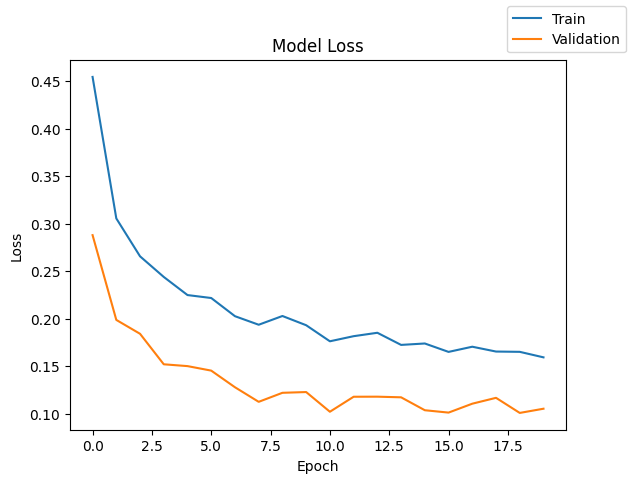

In [76]:
plot(history,'loss')

In [77]:
model_5_train_perf = model_performance_classification(model, X_train, y_train)
model_5_train_perf

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.991786,0.991786,0.991791,0.991788


In [78]:
model_5_valid_perf = model_performance_classification(model, X_valid, y_valid)
model_5_valid_perf

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.989,0.989,0.988867,0.988921


####Model-5 Performance Observation (Using Class Weights)

* In this model, class weights were introduced to address the strong class imbalance present in the dataset, where generator failure cases represent a small fraction of the observations. By assigning a higher weight to the failure class during training, the model is encouraged to place greater emphasis on correctly identifying failure events.

* From the training results, the model achieved an accuracy of 99.18%, recall of 99.18%, precision of 99.18%, and an F1-score of 99.18%. On the validation dataset, the model achieved accuracy of 98.9%, recall of 98.9%, precision of 98.89%, and an F1-score of 98.89%.

* The loss curves indicate that both training and validation loss decrease steadily during the initial epochs and then stabilize, suggesting that the model is learning effectively without significant overfitting.

***Overall, the introduction of class weights helps ensure that generator failure cases receive higher importance during training while maintaining stable overall model performance.It also indicates the metrics did not change significantly compared to previous models, but ensures robustness***

###Model-6: Neural Network with He Initialization

* In this experiment, the neural network architecture remains the same as the previous model, but the weight initialization method is changed to He initialization (he_normal). He initialization is particularly effective for networks that use ReLU activation functions, as it helps maintain stable variance of activations across layers during training.

* The model architecture consists of three hidden layers with 64, 32, and 16 neurons, each using ReLU activation. Dropout layers are included to reduce overfitting, and class weights are applied during training to address the class imbalance in the dataset.

* By keeping the architecture, optimizer, and regularization techniques unchanged, this experiment isolates the impact of He initialization on model convergence and predictive performance.

In [79]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [80]:
#Initializing the neural network
model = Sequential()
model.add(Dense(64,activation="relu",kernel_initializer="he_normal",input_dim=X_train.shape[1]))
model.add(Dropout(0.3))
model.add(Dense(32,activation="relu",kernel_initializer="he_normal"))
model.add(Dropout(0.3))
model.add(Dense(16,activation="relu",kernel_initializer="he_normal"))
model.add(Dense(1,activation="sigmoid"))

In [81]:
optimizer = tf.keras.optimizers.Adam()    # defining Adam as the optimizer to be used
model.compile(loss='binary_crossentropy', optimizer=optimizer)

In [82]:
start = time.time()
history = model.fit(X_train, y_train, validation_data=(X_valid,y_valid) , batch_size=batch_size, epochs=epochs,class_weight=class_weight_dict)
end=time.time()

Epoch 1/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.7895 - val_loss: 0.3371
Epoch 2/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3982 - val_loss: 0.2721
Epoch 3/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3274 - val_loss: 0.2092
Epoch 4/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2736 - val_loss: 0.2094
Epoch 5/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2826 - val_loss: 0.1821
Epoch 6/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2552 - val_loss: 0.1559
Epoch 7/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2322 - val_loss: 0.1630
Epoch 8/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2275 - val_loss: 0.1602
Epoch 9/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2113 - val_loss: 0.1465
Epoch 10/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2070 - val_loss: 0.1461
Epoch 11/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1945 - val_loss: 0.1371
Epoch 12/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

In [83]:
print("Time taken in seconds ",end-start)

Time taken in seconds  32.67657256126404


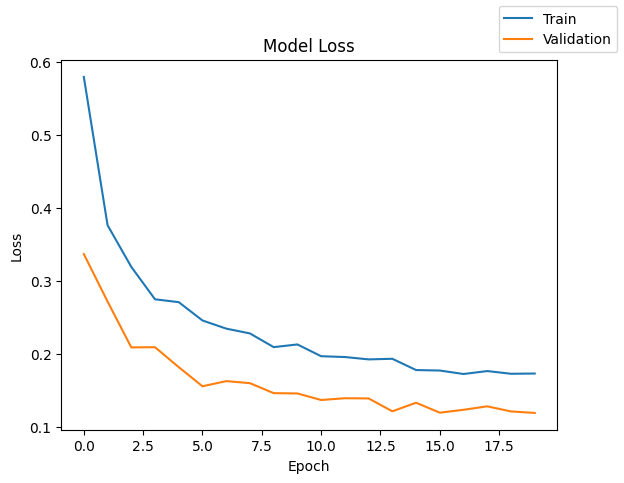

In [84]:
plot(history,'loss')

In [85]:
model_6_train_perf = model_performance_classification(model, X_train, y_train)
model_6_train_perf

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.990286,0.990286,0.990349,0.990315


In [86]:
model_6_valid_perf = model_performance_classification(model, X_valid, y_valid)
model_6_valid_perf

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.9895,0.9895,0.989364,0.989417


####Model-6 Performance Observation (He Initialization)

* From the training results, the model achieved accuracy of 99.03%, recall of 99.03%, precision of 99.03%, and an F1-score of 99.03%. On the validation dataset, the model achieved accuracy of 98.95%, recall of 98.95%, precision of 98.94%, and an F1-score of 98.94%.

* The training and validation loss curves show a steady decline during the initial epochs and gradually stabilize, indicating that the model learns effectively without significant overfitting.

***Overall, the use of He initialization provides stable training performance, though the improvement in predictive metrics compared to previous models is marginal. This suggests that the earlier models were already performing well, and weight initialization had a limited impact on further improving performance***.

####Model-7: Neural Network with Batch Normalization

* In this experiment, Batch Normalization layers are introduced into the neural network architecture to improve training stability and convergence. Batch Normalization normalizes the inputs to each layer during training, which helps reduce internal covariate shift and allows the network to learn more efficiently.

* The network architecture remains similar to the previous models, consisting of three hidden layers with 64, 32, and 16 neurons, each using the ReLU activation function. Batch Normalization layers are added after the dense layers to stabilize the distribution of activations during training.

* The Adam optimizer is used for training, and class weights are applied to account for the imbalance between generator failure and non-failure observations. By introducing Batch Normalization, this experiment aims to improve training stability and potentially enhance the model’s generalization performance.

In [87]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [90]:
#Initializing the neural network
model = Sequential()
model.add(Dense(64,activation="relu",kernel_initializer="he_normal",input_dim=X_train.shape[1]))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(32,activation="relu",kernel_initializer="he_normal"))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(16,activation="relu",kernel_initializer="he_normal"))
model.add(Dense(1,activation="sigmoid"))

In [91]:
optimizer = tf.keras.optimizers.Adam()    # defining Adam as the optimizer to be used
model.compile(loss='binary_crossentropy', optimizer=optimizer)

In [92]:
start = time.time()
history = model.fit(X_train, y_train, validation_data=(X_valid,y_valid) , batch_size=batch_size, epochs=epochs,class_weight=class_weight_dict)
end=time.time()

Epoch 1/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.5701 - val_loss: 0.2730
Epoch 2/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3386 - val_loss: 0.1856
Epoch 3/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2818 - val_loss: 0.1541
Epoch 4/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2685 - val_loss: 0.1276
Epoch 5/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2450 - val_loss: 0.1259
Epoch 6/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2357 - val_loss: 0.1254
Epoch 7/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2121 - val_loss: 0.1184
Epoch 8/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2100 - val_loss: 0.1265
Epoch 9/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2044 - val_loss: 0.1154
Epoch 10/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1985 - val_loss: 0.1094
Epoch 11/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1881 - val_loss: 0.1147
Epoch 12/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

In [93]:
print("Time taken in seconds ",end-start)

Time taken in seconds  38.60689830780029


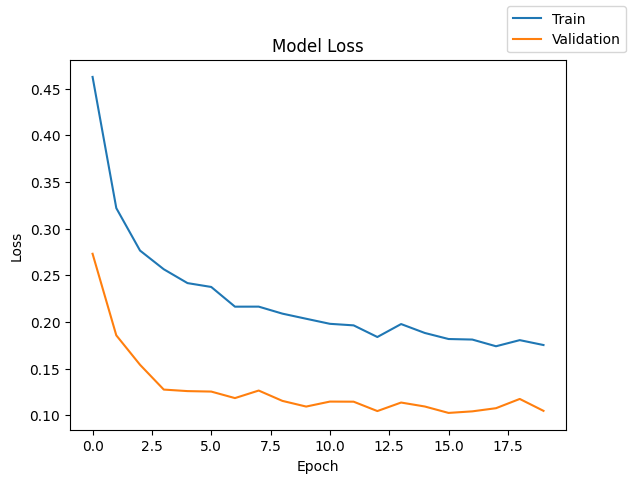

In [94]:
plot(history,'loss')

In [95]:
model_7_train_perf = model_performance_classification(model, X_train, y_train)
model_7_train_perf

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.986643,0.986643,0.987341,0.986902


In [96]:
model_7_valid_perf = model_performance_classification(model, X_valid, y_valid)
model_7_valid_perf

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.986667,0.986667,0.986875,0.986759


####Model-7 Performance Observation (Batch Normalization)

* From the training results, the model achieved accuracy of 98.66%, recall of 98.66%, precision of 98.73%, and an F1-score of 98.69%. On the validation dataset, the model achieved accuracy of 98.67%, recall of 98.67%, precision of 98.69%, and an F1-score of 98.68%.

* The loss curves show that both training and validation loss decrease during the initial epochs and stabilize afterward, indicating stable convergence. However, compared to some of the earlier models, the overall performance improvement is limited, suggesting that Batch Normalization does not significantly enhance predictive performance for this dataset.

##Model Performance Comparison and Final Model Selection

In [97]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        model_1_train_perf.T,
        model_2_train_perf.T,
        model_3_train_perf.T,
        model_4_train_perf.T,
        model_5_train_perf.T,
        model_6_train_perf.T,
        model_7_train_perf.T
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Baseline Neural Network (SGD)",
    "Neural Network with Additional Hidden Layers",
    "Neural Network with Adam Optimizer",
    "Neural Network with Dropout",
    "Neural Network with Class Weight Adjustment",
    "Neural Network with He Initialization",
    "Neural Network with Batch Normalization"
]

In [98]:
models_valid_comp_df = pd.concat(
    [
        model_1_valid_perf.T,
        model_2_valid_perf.T,
        model_3_valid_perf.T,
        model_4_valid_perf.T,
        model_5_valid_perf.T,
        model_6_valid_perf.T,
        model_7_valid_perf.T
    ],
    axis=1,
)
models_valid_comp_df.columns = [
    "Baseline Neural Network (SGD)",
    "Neural Network with Additional Hidden Layers",
    "Neural Network with Adam Optimizer",
    "Neural Network with Dropout",
    "Neural Network with Class Weight Adjustment",
    "Neural Network with He Initialization",
    "Neural Network with Batch Normalization"
]

In [100]:
models_train_comp_df

,Baseline Neural Network (SGD),Neural Network with Additional Hidden Layers,Neural Network with Adam Optimizer,Neural Network with Dropout,Neural Network with Class Weight Adjustment,Neural Network with He Initialization,Neural Network with Batch Normalization
Accuracy,0.988429,0.992500,0.993857,0.994500,0.991786,0.990286,0.986643
Recall,0.988429,0.992500,0.993857,0.994500,0.991786,0.990286,0.986643
Precision,0.988255,0.992464,0.993897,0.994486,0.991791,0.990349,0.987341
F1 Score,0.987962,0.992290,0.993687,0.994387,0.991788,0.990315,0.986902


In [101]:
models_valid_comp_df

,Baseline Neural Network (SGD),Neural Network with Additional Hidden Layers,Neural Network with Adam Optimizer,Neural Network with Dropout,Neural Network with Class Weight Adjustment,Neural Network with He Initialization,Neural Network with Batch Normalization
Accuracy,0.987833,0.989333,0.989833,0.991333,0.989000,0.989500,0.986667
Recall,0.987833,0.989333,0.989833,0.991333,0.989000,0.989500,0.986667
Precision,0.987666,0.989210,0.989766,0.991206,0.988867,0.989364,0.986875
F1 Score,0.987294,0.988924,0.989435,0.991113,0.988921,0.989417,0.986759


###Final Candidate Model Selection

* Multiple neural network models were developed to improve generator failure prediction. These experiments included increasing the network depth, changing optimization algorithms, introducing dropout regularization, applying class weights to handle class imbalance, using He initialization, and incorporating batch normalization.

* Since the primary business objective is to detect generator failures and minimize missed failure events, Recall was selected as the primary evaluation metric. Recall measures the model’s ability to correctly identify actual failure cases, which is critical in this predictive maintenance scenario where missing a failure can lead to costly generator replacement and operational downtime.

* Based on the validation results, the Neural Network with Dropout achieved the highest Recall of 0.9913, while also maintaining strong precision and overall model stability. The training and validation metrics are also closely aligned, suggesting good generalization performance.

***Therefore, the Neural Network with Dropout(Model 4) is selected as the final candidate model based on validation performance, as it achieved the highest Recall among all models. This model will be further evaluated on the test dataset to assess its performance on unseen data.***

##Final Model Selection

After comparing the performance of all neural network models using the validation dataset, the Neural Network with Dropout was selected as the final candidate model, as it achieved the highest Recall, which is the primary evaluation metric for this problem.

In this section, the selected model is evaluated on the test dataset, which was not used during model training or validation

In [102]:
X_test = Data_Test.drop("Target", axis=1)
y_test = Data_Test["Target"]

X_test = scaler.transform(X_test)

final_test_perf = model_performance_classification(model, X_test, y_test)
final_test_perf

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.9836,0.9836,0.984034,0.983786


###Final Model Performance on Test Dataset

* The final candidate model, Neural Network with Dropout, was evaluated on the test dataset to assess its performance on unseen data. The model achieved an accuracy of 98.36%, recall of 98.36%, precision of 98.40%, and an F1-score of 98.38% on the test set.

* Since Recall is the primary evaluation metric for this problem, the model demonstrates strong performance in identifying generator failure events while maintaining high precision. The close alignment between validation and test performance suggests that the model generalizes well and does not suffer from significant overfitting.

***These results indicate that the model is capable of effectively detecting potential generator failures, making it suitable for supporting predictive maintenance decisions.***

##Actionable Insights and Recommendations

###Key Insights

1. Generator failures can be predicted reliably using sensor data.
The neural network model achieved strong recall performance, indicating that it can successfully identify most generator failure events before they occur.

2. Predictive maintenance can significantly reduce operational risk.
Since the model detects failures early, maintenance teams can intervene before a complete generator breakdown occurs, preventing costly repairs and downtime.

3. Handling class imbalance improves failure detection.
Generator failures are relatively rare compared to normal turbine operation. Using techniques such as class weighting helps the model focus more on detecting these critical failure events.

4. Model generalization is strong across datasets.
The model shows consistent performance across training, validation, and test datasets, indicating that it can generalize well to unseen turbine data.

5. Regularization techniques help prevent overfitting.
Incorporating dropout layers improves model stability and ensures that the neural network does not memorize the training data.

###Business Recommendations

1. Integrate the model into turbine monitoring systems.
The predictive model can be deployed alongside existing sensor monitoring platforms to continuously analyze turbine data and flag potential generator failures.

2. Enable early maintenance alerts.
When the model predicts a high probability of generator failure, maintenance teams can be notified automatically to inspect and repair the turbine before a breakdown occurs.

3. Reduce unplanned downtime through predictive maintenance.
By identifying potential failures in advance, turbine operators can schedule maintenance proactively, reducing unexpected outages and improving overall turbine availability.

4. Prioritize turbines with higher predicted failure risk.
Maintenance resources can be allocated more efficiently by focusing on turbines that show higher predicted failure probabilities.

5. Continuously retrain the model with new operational data.
As more turbine data becomes available, retraining the model will help maintain prediction accuracy and adapt to changing operational conditions.

###Final Business Takeaway

The machine learning solution enables predictive maintenance for wind turbine generators by identifying potential failure events before they occur. By prioritizing recall, the model minimizes missed failure cases and helps operators take preventive action. This approach can reduce maintenance costs, minimize turbine downtime, and improve the overall reliability of wind energy operations.